# CIFAR-10-C: Multi-Conformal + Multi-Detector Drift

Compares multiple conformal prediction frameworks on CIFAR-10-C and evaluates MMD, KS, and CUSUM for online drift detection.

In [1]:
import math
import os

import matplotlib
if os.environ.get('HEADLESS', '0') == '1':
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

ALPHA = 0.10
EPOCHS = 10
BATCH_SIZE = 128
SEED = 42
STREAM_CLEAN_BATCHES = 20
STREAM_NOISY_BATCHES = 20
STREAM_WINDOW = 5
MMD_PERMUTATIONS = 300
KS_PERMUTATIONS = 300
CUSUM_K = 0.5
CUSUM_H = 5.0
TARGET_CORRUPTION = 'gaussian_noise'
TARGET_SEVERITY = 3

DATA_C_DIR = '/data/CIFAR-10-C'
if not os.path.exists(DATA_C_DIR):
    p = './data/CIFAR-10-C'
    DATA_C_DIR = p if os.path.exists(p) else './playground/data/CIFAR-10-C'
OUTPUT_DIR = './playground' if os.path.isdir('./playground') else '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)

FORCE_RETRAIN = False
# Recompute predictor outputs only when needed; otherwise load cached CSV artifacts.
FORCE_RERUN_PREDICTORS = False
MODEL_CKPT_PATH = os.path.join(OUTPUT_DIR, f'simplecnn_cifar10_seed{SEED}_ep{EPOCHS}.pt')
MULTI_RESULTS_CSV = os.path.join(OUTPUT_DIR, 'multi_conformal_cifar10c_results.csv')
FW_STREAM_CSV = os.path.join(OUTPUT_DIR, 'conformal_framework_stream_metrics.csv')
EFFICIENCY_CSV = os.path.join(OUTPUT_DIR, 'conformal_drift_efficiency_summary.csv')

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)

CORRUPTIONS = sorted([f[:-4] for f in os.listdir(DATA_C_DIR) if f.endswith('.npy') and f != 'labels.npy'])
print('Device:', device)
print('Corruptions:', len(CORRUPTIONS))
print('Target stream:', f'{TARGET_CORRUPTION} severity {TARGET_SEVERITY}')

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize(mean, std)])
test_tf = T.Compose([T.ToTensor(), T.Normalize(mean, std)])

train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_tf)
test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)
gen = torch.Generator().manual_seed(SEED)
cal_ds, hold_ds = random_split(test_ds, [len(test_ds)//2, len(test_ds)-len(test_ds)//2], generator=gen)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
cal_loader = DataLoader(cal_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
hold_loader = DataLoader(hold_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Dataset sizes -> train: {len(train_ds):,}, cal: {len(cal_ds):,}, hold-out: {len(hold_ds):,}')

class SimpleCNN(nn.Module):
    def __init__(self, n=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d(4),
        )
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(128*4*4, 256)
        self.drop = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, n)

    def forward(self, x):
        h = self.features(x)
        h = torch.relu(self.fc1(self.flat(h)))
        return self.fc2(self.drop(h))

    def get_embeddings(self, x):
        h = self.features(x)
        return torch.relu(self.fc1(self.flat(h)))

def train_epoch(m, loader, opt, crit):
    m.train(); loss_sum=0.0; ok=0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); logits = m(xb); loss = crit(logits, yb)
        loss.backward(); opt.step()
        loss_sum += loss.item()*len(yb); ok += (logits.argmax(1)==yb).sum().item()
    n = len(loader.dataset); return loss_sum/n, ok/n

@torch.no_grad()
def collect_probs(m, loader):
    m.eval(); ps=[]; ys=[]
    for xb, yb in loader:
        ps.append(torch.softmax(m(xb.to(device)), dim=1).cpu()); ys.append(yb.cpu())
    return torch.cat(ps), torch.cat(ys)

def load_c_loader(corr, sev, batch_size=256):
    X = np.load(os.path.join(DATA_C_DIR, f'{corr}.npy'))[(sev-1)*10000:sev*10000]
    y = np.load(os.path.join(DATA_C_DIR, 'labels.npy'))[(sev-1)*10000:sev*10000]
    Xt = torch.tensor(X, dtype=torch.float32).permute(0,3,1,2)/255.0
    mu = torch.tensor(mean).view(3,1,1); sg = torch.tensor(std).view(3,1,1)
    Xt = (Xt-mu)/sg
    return DataLoader(TensorDataset(Xt, torch.tensor(y, dtype=torch.long)), batch_size=batch_size, shuffle=False, num_workers=0)

model = SimpleCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
crit = nn.CrossEntropyLoss()
if (not FORCE_RETRAIN) and os.path.exists(MODEL_CKPT_PATH):
    model.load_state_dict(torch.load(MODEL_CKPT_PATH, map_location=device)); model.eval(); print('Loaded', MODEL_CKPT_PATH)
else:
    print('Training model from scratch...')
    for ep in range(1, EPOCHS+1):
        trl, tra = train_epoch(model, train_loader, opt, crit); sch.step(); print(f'Epoch {ep}/{EPOCHS} loss {trl:.4f} acc {tra:.3f}')
    torch.save(model.state_dict(), MODEL_CKPT_PATH); print('Saved', MODEL_CKPT_PATH)


Device: cpu
Corruptions: 19
Target stream: gaussian_noise severity 3


C:\Users\joobzm\Desktop\dacal-stream-learning\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Dataset sizes -> train: 50,000, cal: 5,000, hold-out: 5,000
Loaded .\simplecnn_cifar10_seed42_ep10.pt


In [3]:
def qhat(scores, alpha):
    s = torch.as_tensor(scores, dtype=torch.float32); n=len(s)
    k=min(math.ceil((n+1)*(1-alpha)), n)
    return s.sort().values[k-1].item()

def lac_cal(p,y,a):
    return {'q': qhat(1.0-p[torch.arange(len(y)), y], a)}
def lac_set(p, prm):
    return (1.0-p) <= prm['q']

def mond_cal(p,y,a,nc=10):
    d={}
    for c in range(nc):
        idx=(y==c); sc=1.0-p[idx, c]
        d[c]=1.0 if len(sc)==0 else qhat(sc,a)
    return {'q': d}
def mond_set(p, prm):
    q = torch.tensor([prm['q'][c] for c in range(p.shape[1])], dtype=p.dtype)
    return (1.0-p) <= q.view(1,-1)

def aps_cal(p,y,a):
    sp, si = torch.sort(p, dim=1, descending=True); cs = sp.cumsum(1)
    pos = (si==y.view(-1,1)).nonzero(as_tuple=False)
    s = cs[pos[:,0], pos[:,1]]
    return {'q': qhat(s,a)}
def aps_set(p, prm):
    sp, si = torch.sort(p, dim=1, descending=True); cs = sp.cumsum(1)
    keep = cs <= prm['q']; keep[:,0]=True
    out = torch.zeros_like(p, dtype=torch.bool); out.scatter_(1, si, keep)
    return out

def topk_cal(p,y,a):
    si = torch.argsort(p, dim=1, descending=True)
    rank = (si==y.view(-1,1)).nonzero(as_tuple=False)[:,1] + 1
    return {'k': int(qhat(rank.float(), a))}
def topk_set(p, prm):
    idx = torch.argsort(p, dim=1, descending=True)[:, :prm['k']]
    out = torch.zeros_like(p, dtype=torch.bool); out.scatter_(1, idx, True)
    return out

FW = {
    'Global-LAC': (lac_cal, lac_set),
    'Mondrian-LAC': (mond_cal, mond_set),
    'APS': (aps_cal, aps_set),
    'TopK': (topk_cal, topk_set),
}

@torch.no_grad()
def eval_fw(m, loader, set_fn, prm):
    cov=0; tot=0; sizes=[]
    for xb, yb in loader:
        p = torch.softmax(m(xb.to(device)), dim=1).cpu()
        ps = set_fn(p, prm)
        cov += ps[torch.arange(len(yb)), yb].sum().item(); tot += len(yb); sizes.extend(ps.sum(1).tolist())
    return cov/tot, float(np.mean(sizes))

cal_p = None
cal_y = None
params = None
if (not FORCE_RERUN_PREDICTORS) and os.path.exists(MULTI_RESULTS_CSV):
    df = pd.read_csv(MULTI_RESULTS_CSV)
    print('Loaded', MULTI_RESULTS_CSV)
else:
    cal_p, cal_y = collect_probs(model, cal_loader)
    print('Calibrating conformal frameworks...')
    params = {name: cal_fn(cal_p, cal_y, ALPHA) for name, (cal_fn, _) in FW.items()}
    print('Calibration complete for:', ', '.join(FW.keys()))

    rows=[]
    for name, (_, set_fn) in FW.items():
        print(f'[{name}] evaluating clean hold-out...')
        c,s = eval_fw(model, hold_loader, set_fn, params[name])
        rows.append({'framework':name, 'corruption':'clean_holdout', 'severity':0, 'coverage':c, 'avg_set_size':s})
        for corr in CORRUPTIONS:
            print(f'[{name}] corruption: {corr}')
            for sev in range(1,6):
                ld = load_c_loader(corr, sev, BATCH_SIZE)
                c,s = eval_fw(model, ld, set_fn, params[name])
                rows.append({'framework':name, 'corruption':corr, 'severity':sev, 'coverage':c, 'avg_set_size':s})

    df = pd.DataFrame(rows)
    df.to_csv(MULTI_RESULTS_CSV, index=False)
    print('Saved', MULTI_RESULTS_CSV)

summary = df[df.severity>0].groupby(['framework','severity'])['coverage'].mean().reset_index()
leader = df[df.severity>0].groupby('framework')[['coverage','avg_set_size']].mean().sort_values('coverage', ascending=False)
display(leader)


Loaded .\multi_conformal_cifar10c_results.csv


,coverage,avg_set_size
framework,,
APS,0.961296,4.895249
TopK,0.777649,2.000000
Global-LAC,0.746837,1.558368
Mondrian-LAC,0.739898,1.666963


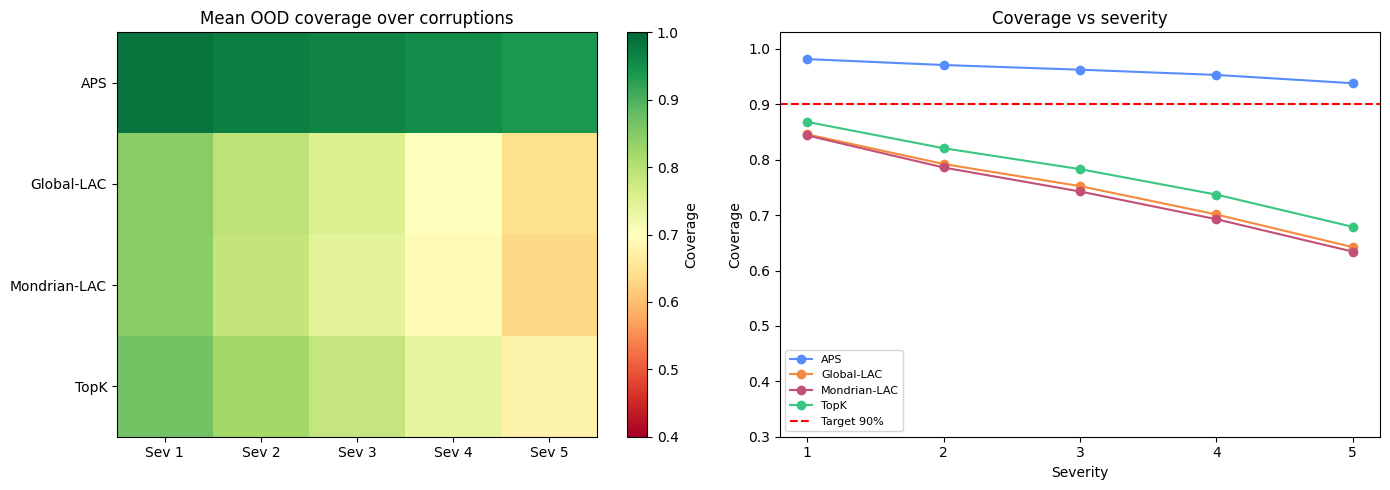

Saved .\multi_conformal_coverage_summary.png


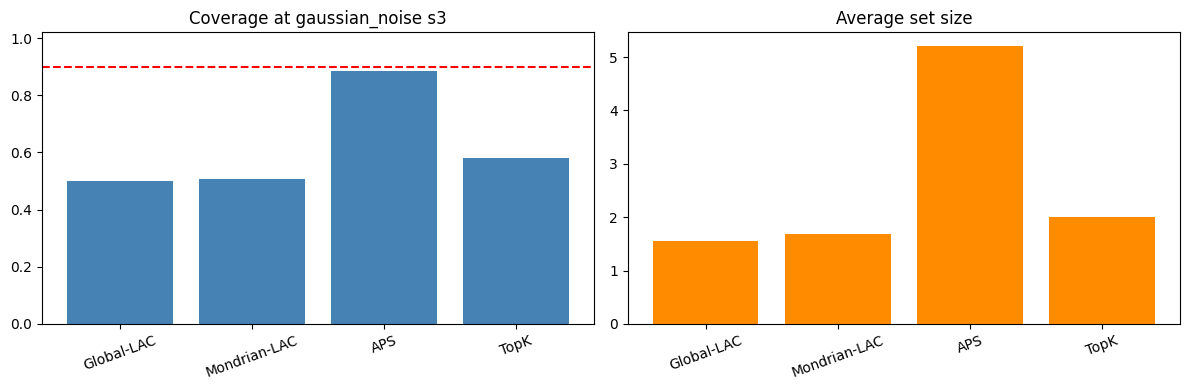

Saved .\multi_conformal_spotcheck.png
Visualization stage complete.


In [4]:
pv = summary.pivot(index='framework', columns='severity', values='coverage')
fig, ax = plt.subplots(1,2, figsize=(14,5))
im = ax[0].imshow(pv.values, aspect='auto', vmin=0.4, vmax=1.0, cmap='RdYlGn')
ax[0].set_yticks(np.arange(len(pv.index))); ax[0].set_yticklabels(pv.index)
ax[0].set_xticks(np.arange(5)); ax[0].set_xticklabels([f'Sev {i}' for i in range(1,6)])
ax[0].set_title('Mean OOD coverage over corruptions')
plt.colorbar(im, ax=ax[0], label='Coverage')
for fw in pv.index:
    ax[1].plot(range(1,6), pv.loc[fw].values, marker='o', label=fw)
ax[1].axhline(1-ALPHA, color='red', ls='--', label=f'Target {1-ALPHA:.0%}')
ax[1].set_ylim(0.3, 1.03); ax[1].set_xticks(range(1,6))
ax[1].set_xlabel('Severity'); ax[1].set_ylabel('Coverage')
ax[1].set_title('Coverage vs severity'); ax[1].legend(fontsize=8)
plt.tight_layout()
p1 = os.path.join(OUTPUT_DIR, 'multi_conformal_coverage_summary.png')
plt.savefig(p1, dpi=150, bbox_inches='tight'); plt.show(); print('Saved', p1)

spot = df[(df.corruption==TARGET_CORRUPTION) & (df.severity==TARGET_SEVERITY)]
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].bar(spot.framework, spot.coverage, color='steelblue'); ax[0].axhline(1-ALPHA, color='red', ls='--')
ax[0].set_ylim(0,1.02); ax[0].set_title(f'Coverage at {TARGET_CORRUPTION} s{TARGET_SEVERITY}'); ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(spot.framework, spot.avg_set_size, color='darkorange'); ax[1].set_title('Average set size'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
p2 = os.path.join(OUTPUT_DIR, 'multi_conformal_spotcheck.png')
plt.savefig(p2, dpi=150, bbox_inches='tight'); plt.show(); print('Saved', p2)
print('Visualization stage complete.')


MMD baseline ready -> threshold=0.000199, sigma=21.389531
KS baseline ready -> threshold=0.040020
CUSUM baseline ready -> mean=-0.014883, std=0.312937, k=0.5, h=5.0
Stream prepared -> clean batches: 20, noisy batches: 20
[stream step 00] CLEAN | warming up window (1/5)
[stream step 01] CLEAN | warming up window (2/5)
[stream step 02] CLEAN | warming up window (3/5)
[stream step 03] CLEAN | warming up window (4/5)
[stream step 04] CLEAN | MMD^2=-0.000383 (a=False) | KS=0.021875 (a=False) | CUSUM=0.0000 (a=False)
[stream step 05] CLEAN | MMD^2=-0.000450 (a=False) | KS=0.034375 (a=False) | CUSUM=0.0000 (a=False)
[stream step 06] CLEAN | MMD^2=-0.000198 (a=False) | KS=0.037500 (a=False) | CUSUM=0.7572 (a=False)
[stream step 07] CLEAN | MMD^2=-0.000665 (a=False) | KS=0.032813 (a=False) | CUSUM=0.5278 (a=False)
[stream step 08] CLEAN | MMD^2=0.000532 (a=True) | KS=0.043750 (a=True) | CUSUM=0.0000 (a=False)
[stream step 09] CLEAN | MMD^2=0.001456 (a=True) | KS=0.039062 (a=False) | CUSUM=0.536

,detector,total_alerts,alerts_in_noisy_phase,first_alert_step,first_alert_delay
0,MMD,25,20,20,0
1,KS,28,20,20,0
2,CUSUM,22,18,22,2


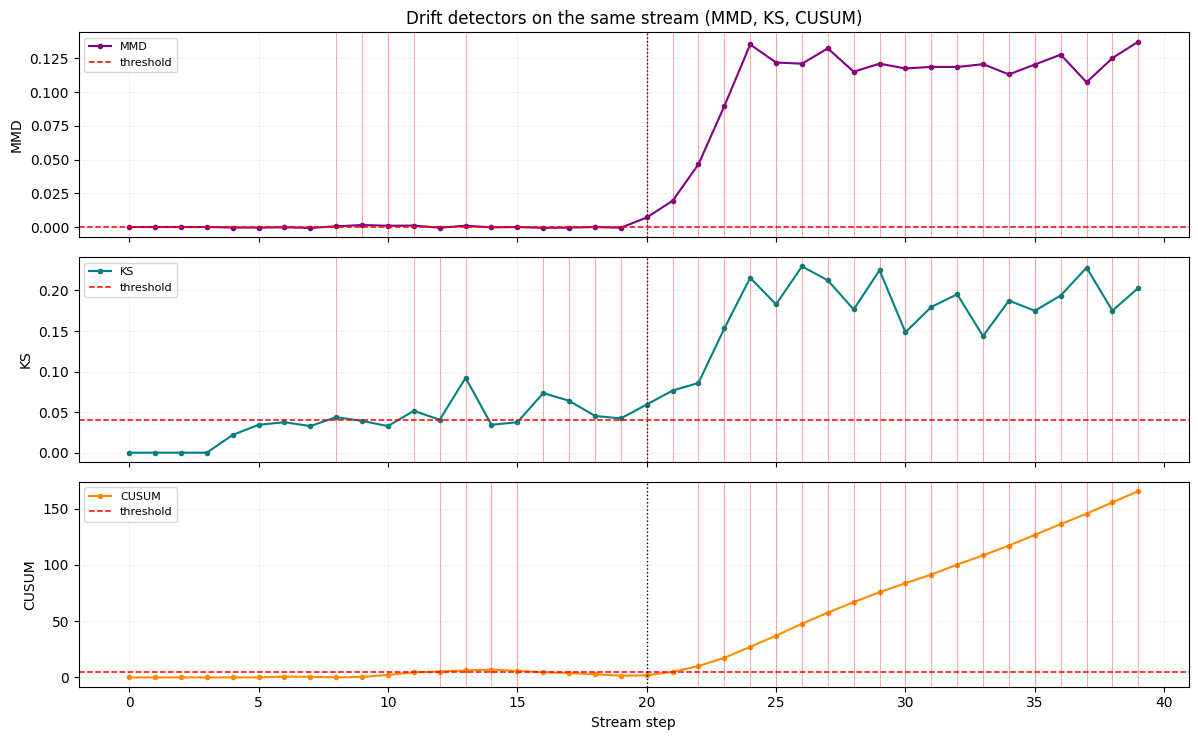

Saved .\drift_detectors_timeline.png
MMD alert steps: [8, 9, 10, 11, 13, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


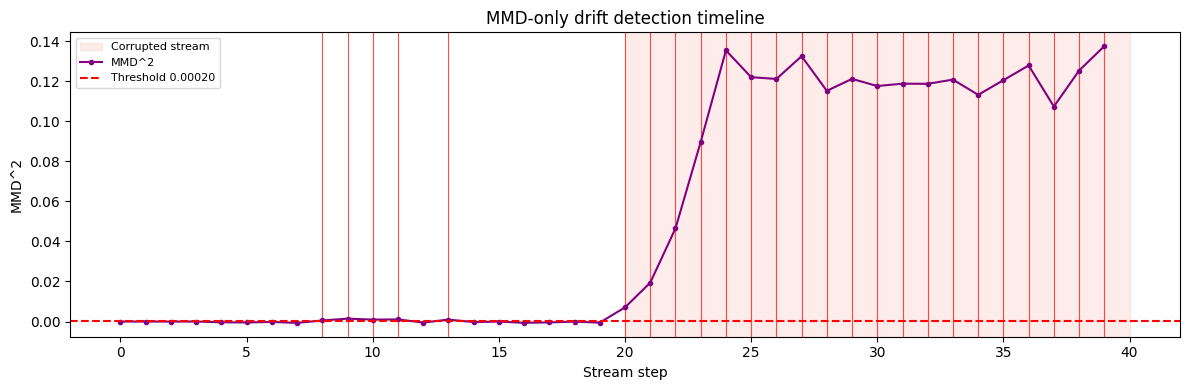

Saved .\mmd_only_drift_timeline.png
Alert steps: [8, 9, 10, 11, 13, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [5]:
class OnlinePCA:
    def __init__(self, n_components=32): self.n=n_components; self.m=None; self.c=None
    def fit(self, X):
        X=X.float(); self.m=X.mean(0); Xc=X-self.m
        _,_,Vt = torch.linalg.svd(Xc, full_matrices=False)
        self.c = Vt[:self.n]; return self
    def transform(self, X): return (X.float()-self.m) @ self.c.T

def _sigma(X):
    if len(X)>500: X = X[torch.randperm(len(X))[:500]]
    return torch.cdist(X,X).median().item() + 1e-6
def _rbf(A,B,s):
    AA=(A**2).sum(1, keepdim=True); BB=(B**2).sum(1, keepdim=True)
    return torch.exp(-(AA + BB.T - 2*A@B.T)/(2*s*s))
def mmd(Xr, Xn, s=None):
    if s is None: s=_sigma(torch.cat([Xr,Xn]))
    n,m=len(Xr),len(Xn)
    Krr=_rbf(Xr,Xr,s); Knn=_rbf(Xn,Xn,s); Krn=_rbf(Xr,Xn,s)
    v=((Krr.sum()-Krr.trace())/(n*(n-1)) + (Knn.sum()-Knn.trace())/(m*(m-1)) - 2*Krn.mean()).item()
    return v,s
def mmd_thr(Xa, Xb, n_perm=300, alpha=0.05):
    Z = torch.cat([Xa, Xb], 0); n=len(Xa); s=_sigma(Z); vals=[]
    for _ in range(n_perm):
        p=torch.randperm(len(Z)); v,_=mmd(Z[p[:n]], Z[p[n:]], s); vals.append(v)
    return float(np.quantile(vals, 1-alpha)), s

def ks_stat(x, y):
    x = np.sort(np.asarray(x, dtype=np.float64))
    y = np.sort(np.asarray(y, dtype=np.float64))
    vals = np.concatenate([x, y])
    cdf_x = np.searchsorted(x, vals, side='right') / max(len(x), 1)
    cdf_y = np.searchsorted(y, vals, side='right') / max(len(y), 1)
    return float(np.max(np.abs(cdf_x - cdf_y)))

def ks_thr(xa, xb, n_perm=300, alpha=0.05):
    xa = np.asarray(xa, dtype=np.float64)
    xb = np.asarray(xb, dtype=np.float64)
    z = np.concatenate([xa, xb])
    n = len(xa)
    vals = []
    for _ in range(n_perm):
        p = np.random.permutation(len(z))
        vals.append(ks_stat(z[p[:n]], z[p[n:]]))
    return float(np.quantile(vals, 1 - alpha))

@torch.no_grad()
def embs(loader):
    out=[]
    for xb,_ in loader: out.append(model.get_embeddings(xb.to(device)).cpu())
    return torch.cat(out)

ref_raw = embs(cal_loader)
pca = OnlinePCA(32).fit(ref_raw)
ref = pca.transform(ref_raw)
thr, sig = mmd_thr(ref[:len(ref)//2], ref[len(ref)//2:], MMD_PERMUTATIONS, 0.05)
ref_1d = ref[:, 0].detach().numpy()
ks_threshold = ks_thr(ref_1d[:len(ref_1d)//2], ref_1d[len(ref_1d)//2:], KS_PERMUTATIONS, 0.05)

cusum_boot = []
for _ in range(400):
    idx = np.random.permutation(len(ref_1d))[:BATCH_SIZE * STREAM_WINDOW]
    cusum_boot.append(float(ref_1d[idx].mean()))
cusum_mu = float(np.mean(cusum_boot))
cusum_sigma = float(np.std(cusum_boot) + 1e-8)
print(f'MMD baseline ready -> threshold={thr:.6f}, sigma={sig:.6f}')
print(f'KS baseline ready -> threshold={ks_threshold:.6f}')
print(f'CUSUM baseline ready -> mean={cusum_mu:.6f}, std={cusum_sigma:.6f}, k={CUSUM_K}, h={CUSUM_H}')

clean_stream = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
noisy_stream = load_c_loader(TARGET_CORRUPTION, TARGET_SEVERITY, BATCH_SIZE)
stream=[]
for i,b in enumerate(clean_stream):
    if i>=STREAM_CLEAN_BATCHES: break
    stream.append(('CLEAN', b))
for i,b in enumerate(noisy_stream):
    if i>=STREAM_NOISY_BATCHES: break
    stream.append((f'NOISY:{TARGET_CORRUPTION}:s{TARGET_SEVERITY}', b))
print(f'Stream prepared -> clean batches: {STREAM_CLEAN_BATCHES}, noisy batches: {STREAM_NOISY_BATCHES}')

win=[]; logs=[]
cusum_pos = 0.0
cusum_neg = 0.0
for step, (src, (xb,_)) in enumerate(stream):
    e = pca.transform(model.get_embeddings(xb.to(device)).cpu()); win.append(e)
    mmd_val=np.nan; mmd_alert=False
    ks_val=np.nan; ks_alert=False
    cusum_score=np.nan; cusum_alert=False
    if len(win)>=STREAM_WINDOW:
        cur=torch.cat(win[-STREAM_WINDOW:]); idx=torch.randperm(len(ref))[:len(cur)]
        mmd_val,_ = mmd(ref[idx], cur, sig); mmd_alert = mmd_val > thr

        cur_1d = cur[:, 0].detach().numpy()
        ref_idx = np.random.permutation(len(ref_1d))[:len(cur_1d)]
        ks_val = ks_stat(ref_1d[ref_idx], cur_1d)
        ks_alert = ks_val > ks_threshold

        score = float(cur_1d.mean())
        z = (score - cusum_mu) / cusum_sigma
        cusum_pos = max(0.0, cusum_pos + z - CUSUM_K)
        cusum_neg = max(0.0, cusum_neg - z - CUSUM_K)
        cusum_score = max(cusum_pos, cusum_neg)
        cusum_alert = cusum_score > CUSUM_H

    logs.append({
        'step': step,
        'source': src,
        'mmd': mmd_val,
        'mmd_alert': mmd_alert,
        'ks': ks_val,
        'ks_alert': ks_alert,
        'cusum': cusum_score,
        'cusum_alert': cusum_alert,
    })
    if np.isnan(mmd_val):
        print(f'[stream step {step:02d}] {src} | warming up window ({len(win)}/{STREAM_WINDOW})')
    else:
        print(
            f'[stream step {step:02d}] {src} | '
            f'MMD^2={mmd_val:.6f} (a={mmd_alert}) | '
            f'KS={ks_val:.6f} (a={ks_alert}) | '
            f'CUSUM={cusum_score:.4f} (a={cusum_alert})'
        )

det_df = pd.DataFrame(logs)
det_df.to_csv(os.path.join(OUTPUT_DIR, 'drift_detectors_stream_log.csv'), index=False)
print('Saved', os.path.join(OUTPUT_DIR, 'drift_detectors_stream_log.csv'))

# Keep the original MMD frame for downstream conformal linkage.
mddf = det_df[['step', 'source', 'mmd', 'mmd_alert']].rename(columns={'mmd_alert': 'alert'})
mddf.to_csv(os.path.join(OUTPUT_DIR, 'mmd_stream_log.csv'), index=False)

detector_cfg = {
    'MMD': {'value_col': 'mmd', 'alert_col': 'mmd_alert', 'threshold': thr, 'color': 'purple'},
    'KS': {'value_col': 'ks', 'alert_col': 'ks_alert', 'threshold': ks_threshold, 'color': 'teal'},
    'CUSUM': {'value_col': 'cusum', 'alert_col': 'cusum_alert', 'threshold': CUSUM_H, 'color': 'darkorange'},
}

det_summary_rows = []
for det_name, cfg in detector_cfg.items():
    alert_steps = det_df[(det_df['step'] >= STREAM_CLEAN_BATCHES) & (det_df[cfg['alert_col']])]['step'].tolist()
    first_alert_step = int(alert_steps[0]) if len(alert_steps) > 0 else np.nan
    det_summary_rows.append({
        'detector': det_name,
        'total_alerts': int(det_df[cfg['alert_col']].sum()),
        'alerts_in_noisy_phase': int(det_df[(det_df['step'] >= STREAM_CLEAN_BATCHES) & (det_df[cfg['alert_col']])].shape[0]),
        'first_alert_step': first_alert_step,
        'first_alert_delay': (first_alert_step - STREAM_CLEAN_BATCHES) if not np.isnan(first_alert_step) else np.nan,
    })

det_summary = pd.DataFrame(det_summary_rows).sort_values('alerts_in_noisy_phase', ascending=False)
det_sum_csv = os.path.join(OUTPUT_DIR, 'drift_detector_summary.csv')
det_summary.to_csv(det_sum_csv, index=False)
print('Saved', det_sum_csv)
display(det_summary)

fig, axes = plt.subplots(3, 1, figsize=(12, 7.5), sharex=True)
for ax, (det_name, cfg) in zip(axes, detector_cfg.items()):
    vals = det_df[cfg['value_col']].fillna(0.0)
    ax.plot(det_df['step'], vals, color=cfg['color'], marker='o', ms=3, label=det_name)
    ax.axhline(cfg['threshold'], color='red', ls='--', lw=1.1, label='threshold')
    ax.axvline(STREAM_CLEAN_BATCHES, color='black', ls=':', lw=1.0)
    for step in det_df[det_df[cfg['alert_col']]]['step'].tolist():
        ax.axvline(step, color='red', lw=0.7, alpha=0.35)
    ax.set_ylabel(det_name)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.2)

axes[0].set_title('Drift detectors on the same stream (MMD, KS, CUSUM)')
axes[-1].set_xlabel('Stream step')
plt.tight_layout()
p3 = os.path.join(OUTPUT_DIR, 'drift_detectors_timeline.png')
plt.savefig(p3, dpi=150, bbox_inches='tight'); plt.show(); print('Saved', p3)

alerts = det_df[det_df['mmd_alert']]['step'].astype(int).tolist()
print('MMD alert steps:', alerts)
mmd_steps = det_df['step'].to_numpy()
mmd_vals = det_df['mmd'].fillna(0.0).to_numpy()

plt.figure(figsize=(12,4))
plt.axvspan(STREAM_CLEAN_BATCHES, float(max(mmd_steps) + 1), color='salmon', alpha=0.15, label='Corrupted stream')
for a in alerts: plt.axvline(a, color='red', lw=0.8, alpha=0.7)
plt.plot(mmd_steps, mmd_vals, color='purple', marker='o', ms=3, label='MMD^2')
plt.axhline(thr, color='red', ls='--', label=f'Threshold {thr:.5f}')
plt.title('MMD-only drift detection timeline')
plt.xlabel('Stream step'); plt.ylabel('MMD^2'); plt.legend(fontsize=8); plt.tight_layout()
p3 = os.path.join(OUTPUT_DIR, 'mmd_only_drift_timeline.png')
plt.savefig(p3, dpi=150, bbox_inches='tight'); plt.show(); print('Saved', p3)
print('Alert steps:', alerts)


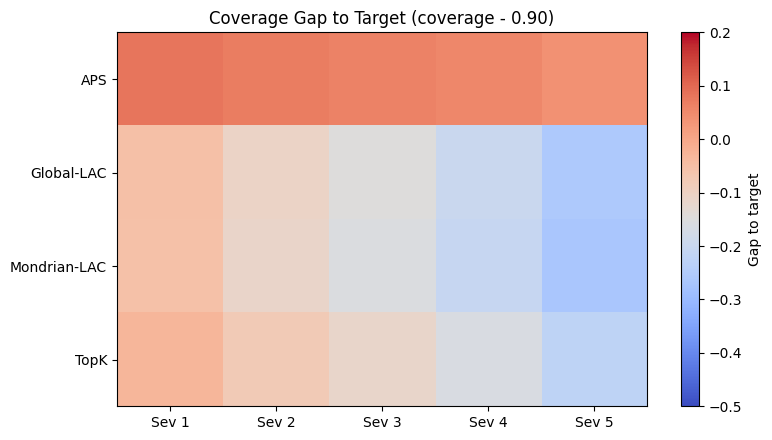

Saved .\multi_conformal_shortfall_heatmap.png


In [6]:
# Coverage shortfall against the conformal target by framework and severity.
shortfall = summary.copy()
shortfall['gap_to_target'] = shortfall['coverage'] - (1 - ALPHA)
shortfall_pivot = shortfall.pivot(index='framework', columns='severity', values='gap_to_target')

plt.figure(figsize=(8, 4.5))
im = plt.imshow(shortfall_pivot.values, aspect='auto', cmap='coolwarm', vmin=-0.5, vmax=0.2)
plt.yticks(np.arange(len(shortfall_pivot.index)), shortfall_pivot.index)
plt.xticks(np.arange(5), [f'Sev {i}' for i in range(1, 6)])
plt.title('Coverage Gap to Target (coverage - 0.90)')
plt.colorbar(im, label='Gap to target')
plt.tight_layout()
p4 = os.path.join(OUTPUT_DIR, 'multi_conformal_shortfall_heatmap.png')
plt.savefig(p4, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', p4)


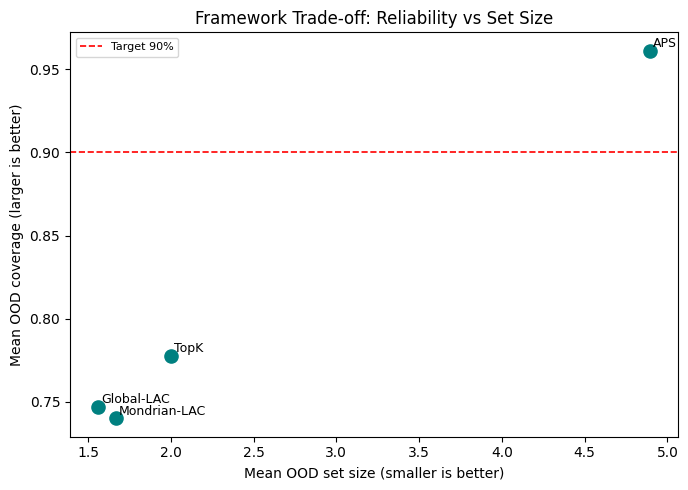

Saved .\multi_conformal_tradeoff_scatter.png


In [7]:
# Efficiency vs reliability trade-off (mean OOD values).
trade = leader.reset_index().rename(columns={'coverage': 'mean_ood_coverage', 'avg_set_size': 'mean_ood_set_size'})

plt.figure(figsize=(7, 5))
plt.scatter(trade['mean_ood_set_size'], trade['mean_ood_coverage'], s=90, color='teal')
for _, r in trade.iterrows():
    plt.text(r['mean_ood_set_size'] + 0.02, r['mean_ood_coverage'] + 0.002, r['framework'], fontsize=9)
plt.axhline(1 - ALPHA, color='red', linestyle='--', linewidth=1.2, label=f'Target {1-ALPHA:.0%}')
plt.xlabel('Mean OOD set size (smaller is better)')
plt.ylabel('Mean OOD coverage (larger is better)')
plt.title('Framework Trade-off: Reliability vs Set Size')
plt.legend(fontsize=8)
plt.tight_layout()
p5 = os.path.join(OUTPUT_DIR, 'multi_conformal_tradeoff_scatter.png')
plt.savefig(p5, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', p5)


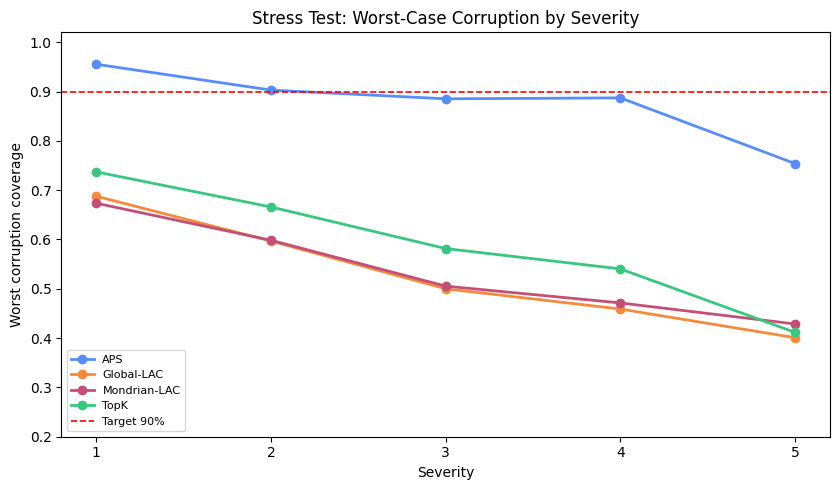

Saved .\multi_conformal_worst_case_by_severity.png


In [8]:
# Worst-case corruption coverage per framework at each severity.
stress = (
    df[df['severity'] > 0]
    .groupby(['framework', 'severity'])['coverage']
    .min()
    .reset_index()
)

plt.figure(figsize=(8.5, 5))
for fw in stress['framework'].unique():
    cur = stress[stress['framework'] == fw].sort_values('severity')
    plt.plot(cur['severity'], cur['coverage'], marker='o', linewidth=2, label=fw)
plt.axhline(1 - ALPHA, color='red', linestyle='--', linewidth=1.2, label=f'Target {1-ALPHA:.0%}')
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0.2, 1.02)
plt.xlabel('Severity')
plt.ylabel('Worst corruption coverage')
plt.title('Stress Test: Worst-Case Corruption by Severity')
plt.legend(fontsize=8)
plt.tight_layout()
p6 = os.path.join(OUTPUT_DIR, 'multi_conformal_worst_case_by_severity.png')
plt.savefig(p6, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', p6)


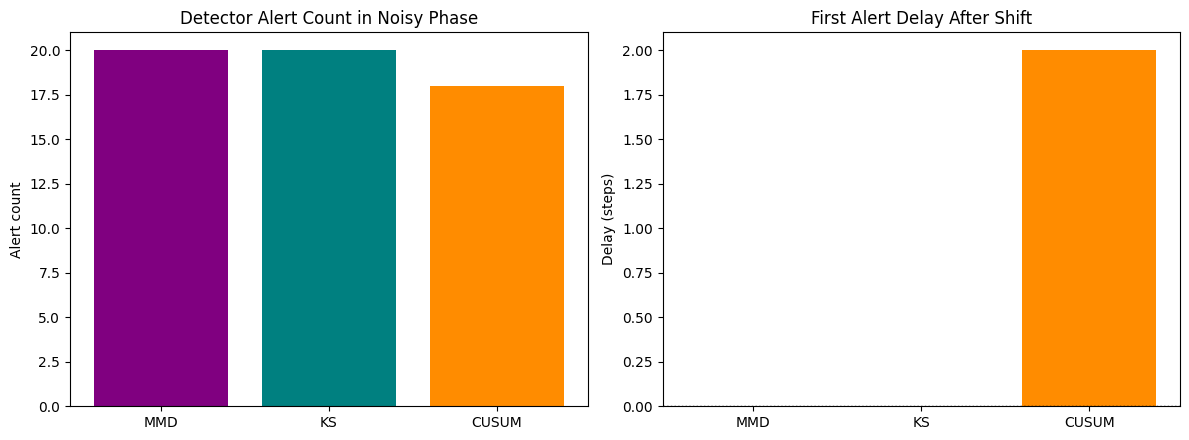

Saved .\drift_detector_comparison.png


In [9]:
# Detector diagnostics: side-by-side alert counts and first-alert delay.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(det_summary['detector'], det_summary['alerts_in_noisy_phase'], color=['purple', 'teal', 'darkorange'])
ax[0].set_title('Detector Alert Count in Noisy Phase')
ax[0].set_ylabel('Alert count')

delay_vals = det_summary['first_alert_delay'].fillna(STREAM_NOISY_BATCHES + 1)
ax[1].bar(det_summary['detector'], delay_vals, color=['purple', 'teal', 'darkorange'])
ax[1].axhline(0.0, color='black', linestyle=':', linewidth=1.0)
ax[1].set_title('First Alert Delay After Shift')
ax[1].set_ylabel('Delay (steps)')

plt.tight_layout()
p7 = os.path.join(OUTPUT_DIR, 'drift_detector_comparison.png')
plt.savefig(p7, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', p7)


In [10]:
# Connect conformal frameworks to drift efficiency on the same stream.
print('Building per-framework stream metrics...')
if (not FORCE_RERUN_PREDICTORS) and os.path.exists(FW_STREAM_CSV):
    fw_stream_df = pd.read_csv(FW_STREAM_CSV)
    print('Loaded', FW_STREAM_CSV)
else:
    if params is None:
        if cal_p is None or cal_y is None:
            cal_p, cal_y = collect_probs(model, cal_loader)
        params = {name: cal_fn(cal_p, cal_y, ALPHA) for name, (cal_fn, _) in FW.items()}

    fw_stream_rows = []
    with torch.no_grad():
        for fw_name, (_, set_fn) in FW.items():
            prm = params[fw_name]
            for step, (source, (xb, yb)) in enumerate(stream):
                probs = torch.softmax(model(xb.to(device)), dim=1).cpu()
                pred_sets = set_fn(probs, prm)
                cov = pred_sets[torch.arange(len(yb)), yb].float().mean().item()
                avg_size = pred_sets.sum(dim=1).float().mean().item()
                fw_stream_rows.append({
                    'framework': fw_name,
                    'step': int(step),
                    'source': source,
                    'coverage': cov,
                    'avg_set_size': avg_size,
                })

    fw_stream_df = pd.DataFrame(fw_stream_rows)
    fw_stream_df.to_csv(FW_STREAM_CSV, index=False)
    print('Saved', FW_STREAM_CSV)

fw_stream_df = fw_stream_df.merge(mddf[['step', 'alert']], on='step', how='left')
fw_stream_df['alert'] = fw_stream_df['alert'].fillna(False)
fw_stream_df['phase'] = np.where(fw_stream_df['step'] < STREAM_CLEAN_BATCHES, 'clean', 'noisy')
print('Per-framework stream rows:', len(fw_stream_df))


Building per-framework stream metrics...
Saved .\conformal_framework_stream_metrics.csv
Per-framework stream rows: 160


In [11]:
# Summary table: how each conformal framework reacts when drift appears.
if (not FORCE_RERUN_PREDICTORS) and os.path.exists(EFFICIENCY_CSV):
    eff_df = pd.read_csv(EFFICIENCY_CSV)
    print('Loaded', EFFICIENCY_CSV)
else:
    clean_stats = (
        fw_stream_df[fw_stream_df['phase'] == 'clean']
        .groupby('framework')[['coverage', 'avg_set_size']]
        .mean()
        .rename(columns={'coverage': 'clean_coverage', 'avg_set_size': 'clean_set_size'})
    )
    noisy_stats = (
        fw_stream_df[fw_stream_df['phase'] == 'noisy']
        .groupby('framework')[['coverage', 'avg_set_size']]
        .mean()
        .rename(columns={'coverage': 'noisy_coverage', 'avg_set_size': 'noisy_set_size'})
    )

    eff_df = clean_stats.join(noisy_stats).reset_index()
    eff_df['coverage_drop'] = eff_df['clean_coverage'] - eff_df['noisy_coverage']
    eff_df['set_size_increase'] = eff_df['noisy_set_size'] - eff_df['clean_set_size']

    alert_steps = mddf[(mddf['alert']) & (mddf['step'] >= STREAM_CLEAN_BATCHES)]['step'].tolist()
    if len(alert_steps) > 0:
        first_alert = int(alert_steps[0])
        alert_size = (
            fw_stream_df[fw_stream_df['step'] == first_alert]
            .set_index('framework')['avg_set_size']
            .rename('set_size_at_first_alert')
        )
        eff_df = eff_df.merge(alert_size, left_on='framework', right_index=True, how='left')
        eff_df['first_alert_set_size_jump'] = eff_df['set_size_at_first_alert'] - eff_df['clean_set_size']
    else:
        eff_df['set_size_at_first_alert'] = np.nan
        eff_df['first_alert_set_size_jump'] = np.nan

    # A simple combined score: smaller coverage drop and larger set-size adaptation are better.
    eff_df['drift_efficiency_score'] = eff_df['set_size_increase'] - eff_df['coverage_drop']

    eff_df.sort_values('drift_efficiency_score', ascending=False).to_csv(EFFICIENCY_CSV, index=False)
    print('Saved', EFFICIENCY_CSV)
display(eff_df.sort_values('drift_efficiency_score', ascending=False))


Loaded .\conformal_drift_efficiency_summary.csv


,framework,clean_coverage,clean_set_size,noisy_coverage,noisy_set_size,coverage_drop,set_size_increase,set_size_at_first_alert,first_alert_set_size_jump,drift_efficiency_score
0,APS,0.988672,3.826953,0.892188,5.208594,0.096484,1.381641,5.164062,1.337109,1.285156
1,Mondrian-LAC,0.895703,1.469141,0.510938,1.697266,0.384766,0.228125,1.695312,0.226172,-0.156641
2,Global-LAC,0.885938,1.390234,0.498828,1.555078,0.387109,0.164844,1.601562,0.211328,-0.222266
3,TopK,0.911719,2.000000,0.581250,2.000000,0.330469,0.000000,2.000000,0.000000,-0.330469


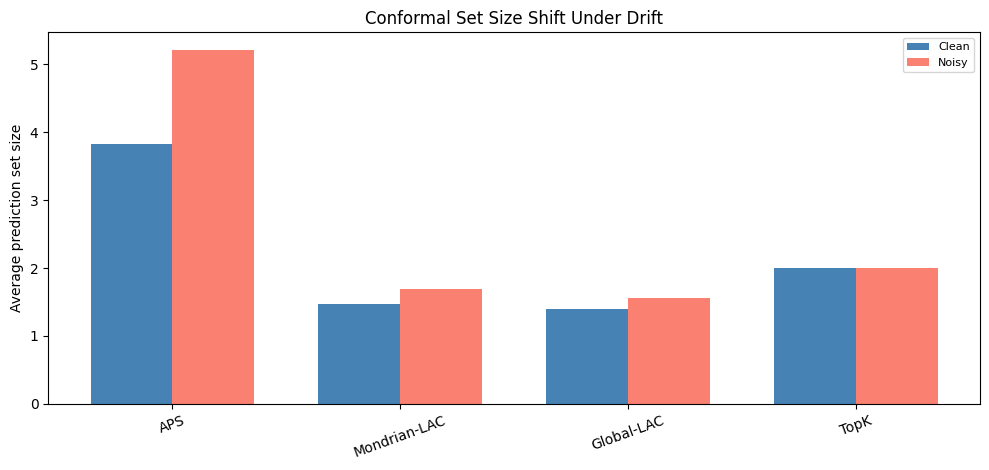

Saved .\conformal_set_size_clean_vs_noisy.png


In [12]:
# Visualization 1: clean vs noisy set-size change per framework.
plot_df = eff_df.sort_values('drift_efficiency_score', ascending=False)
x = np.arange(len(plot_df))
width = 0.36

plt.figure(figsize=(10, 4.8))
plt.bar(x - width/2, plot_df['clean_set_size'], width=width, label='Clean', color='steelblue')
plt.bar(x + width/2, plot_df['noisy_set_size'], width=width, label='Noisy', color='salmon')
plt.xticks(x, plot_df['framework'], rotation=20)
plt.ylabel('Average prediction set size')
plt.title('Conformal Set Size Shift Under Drift')
plt.legend(fontsize=8)
plt.tight_layout()
p8 = os.path.join(OUTPUT_DIR, 'conformal_set_size_clean_vs_noisy.png')
plt.savefig(p8, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', p8)


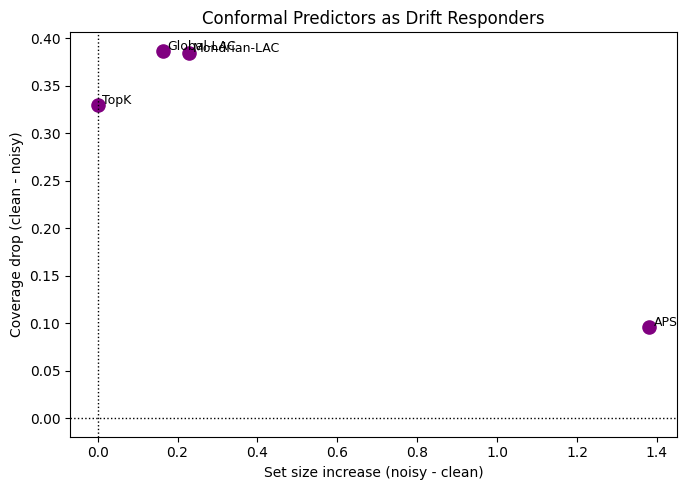

Saved .\conformal_drift_efficiency_scatter.png


In [13]:
# Visualization 2: drift efficiency trade-off (coverage drop vs adaptation).
plt.figure(figsize=(7, 5))
plt.scatter(eff_df['set_size_increase'], eff_df['coverage_drop'], s=90, color='purple')
for _, r in eff_df.iterrows():
    plt.text(r['set_size_increase'] + 0.01, r['coverage_drop'] + 0.001, r['framework'], fontsize=9)
plt.axhline(0.0, color='black', linestyle=':', linewidth=1.0)
plt.axvline(0.0, color='black', linestyle=':', linewidth=1.0)
plt.xlabel('Set size increase (noisy - clean)')
plt.ylabel('Coverage drop (clean - noisy)')
plt.title('Conformal Predictors as Drift Responders')
plt.tight_layout()
p9 = os.path.join(OUTPUT_DIR, 'conformal_drift_efficiency_scatter.png')
plt.savefig(p9, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', p9)


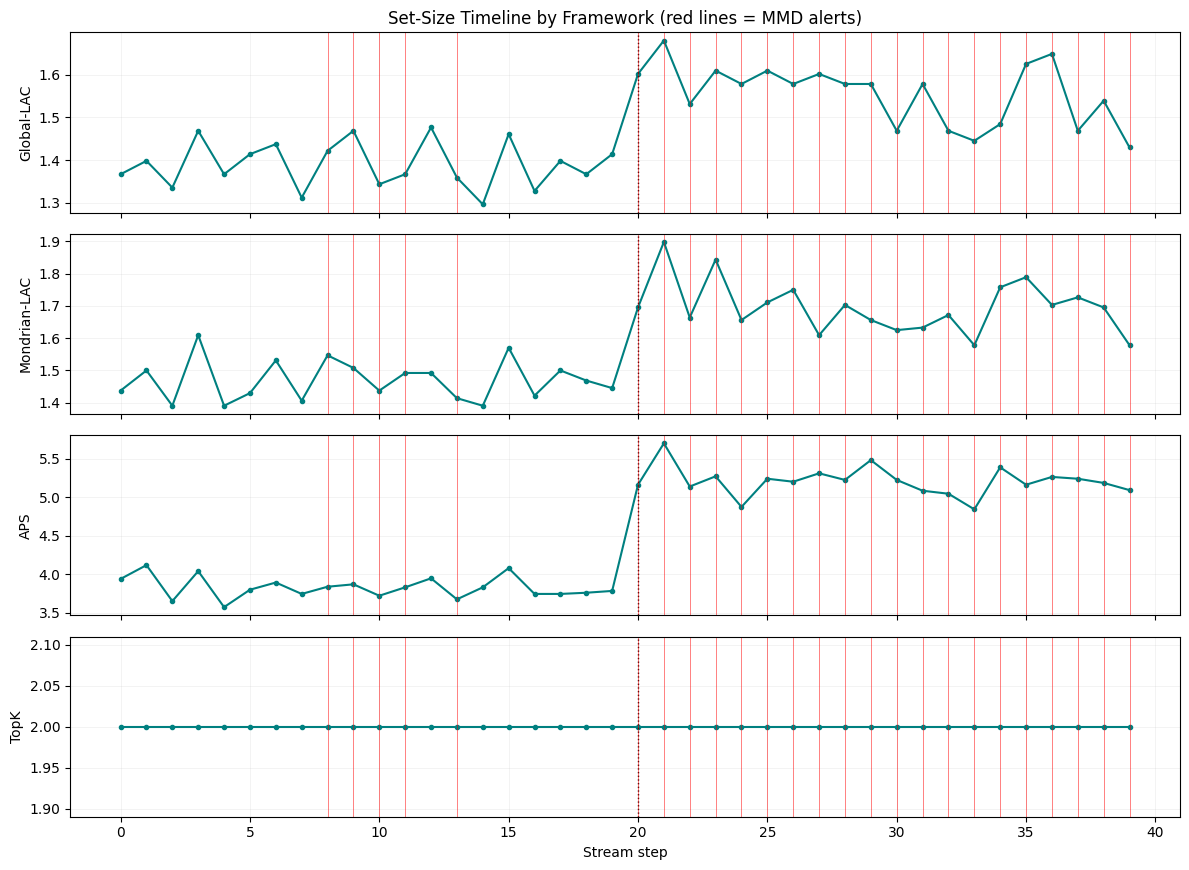

Saved .\conformal_framework_stream_timeline.png


In [14]:
# Visualization 3: per-framework stream timeline with MMD alerts.
fig, axes = plt.subplots(len(FW), 1, figsize=(12, 2.2 * len(FW)), sharex=True)
if len(FW) == 1:
    axes = [axes]

for ax, fw_name in zip(axes, FW.keys()):
    cur = fw_stream_df[fw_stream_df['framework'] == fw_name].sort_values('step')
    ax.plot(cur['step'], cur['avg_set_size'], marker='o', ms=3, color='teal')
    ax.axvline(STREAM_CLEAN_BATCHES, color='black', linestyle=':', linewidth=1.0)
    for a in alerts:
        ax.axvline(a, color='red', linewidth=0.7, alpha=0.5)
    ax.set_ylabel(fw_name)
    ax.grid(alpha=0.2)

axes[0].set_title('Set-Size Timeline by Framework (red lines = MMD alerts)')
axes[-1].set_xlabel('Stream step')
plt.tight_layout()
p10 = os.path.join(OUTPUT_DIR, 'conformal_framework_stream_timeline.png')
plt.savefig(p10, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', p10)
